In [1]:
%cd /home/maia-user/NeuroCBIR/

/home/maia-user/NeuroCBIR


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

### Input data
# Path to dataset
DATA_PATH = "/home/maia-user/cifs/Datasets/"

In [3]:
# Load metadata
import pandas as pd
import os

# Your existing list of DataFrames
clinical_ds = [
    pd.read_csv(os.path.join(DATA_PATH, "ADNI", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "OASIS3", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "AIBL", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "SLIM", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "MIRIAD", "metadata.csv"))
]

# Combine into a single DataFrame
clinical_ds = pd.concat(clinical_ds, axis=0, ignore_index=True)

# (Optional) check shape and columns
print(clinical_ds.shape)
print(clinical_ds.columns)

(26693, 15)
Index(['GUID', 'project', 'subject', 'timepoint', 'scan_type',
       'field_strength', 'manufacturer', 'model_name', 'disease', 'age',
       'brain', 'seg', 'sex', 'acq_date', 'raw'],
      dtype='object')


In [4]:
clinical_ds.manufacturer.unique()

array([nan, 'GE MEDICAL SYSTEMS', 'Philips Medical Systems', 'SIEMENS',
       'Philips Healthcare', 'Siemens'], dtype=object)

In [5]:
disease_mapping = {
    "CN": "CN", "Normal": "CN", "Control": "CN",
    "MCI": "MCI", "Mild Cognitive Impairment": "MCI", "EMCI": "MCI", "LMCI": "MCI", "SMC": "MCI",
    "AD": "AD", "Alzheimer's Disease": "AD"
}

manufacturer_mapping = {
    "Siemens": "SH", "Siemens Healthineers": "SH", "SIEMENS": "SH",
    "GE": "GE", "GE MEDICAL SYSTEMS": "GE"
}


import pandas as pd

# Map disease categories
clinical_ds['disease_cat'] = clinical_ds['disease'].map(disease_mapping).fillna("Other")

# Map manufacturers
clinical_ds['manufacturer_cat'] = clinical_ds['manufacturer'].map(manufacturer_mapping).fillna("Other")

# Function to compute summary per project
def summarize_project(df):
    return pd.Series({
        "NI": len(df),  # total scans
        "NS": df['subject'].nunique(),  # unique subjects
        "Age": f"{df['age'].mean():.1f} ± {df['age'].std():.1f}",  # mean ± std
        "CN": (df['disease_cat'] == "CN").sum(),
        "MCI": (df['disease_cat'] == "MCI").sum(),
        "AD": (df['disease_cat'] == "AD").sum(),
        "Other": (df['disease_cat'] == "Other").sum(),
        "1.5T": (df['field_strength'] == 1.5).sum(),
        "3T": (df['field_strength'] == 3).sum(),
        "SH": (df['manufacturer_cat'] == "SH").sum(),
        "GE": (df['manufacturer_cat'] == "GE").sum(),
        "Other_manufacturer": (df['manufacturer_cat'] == "Other").sum()
    })

# Group and summarize
summary_table = clinical_ds.groupby("project").apply(summarize_project).reset_index()

# Rename columns for display
summary_table.columns = [
    "Dataset", "NI", "NS", "Age", "CN", "MCI", "AD", "Other", "1.5T", "3T", "SH", "GE", "Other"
]

print(summary_table)



  Dataset     NI    NS         Age    CN    MCI    AD  Other  1.5T    3T  \
0    adni  20971  2422  73.6 ± 7.1  6360  11926  2670     15  8114  9101   
1    aibl   1296   691  73.6 ± 6.7   947    184   158      7   269  1027   
2  miriad    708    69  69.7 ± 6.9   243      0   465      0   708     0   
3  oasis3   2681  1316  70.5 ± 9.1  2183    395   102      1   212  2464   
4    slim   1037   588  20.7 ± 1.4  1037      0     0      0     0  1037   

     SH    GE  Other  
0  7587  3662   9722  
1  1296     0      0  
2     0   708      0  
3  2681     0      0  
4  1037     0      0  


/tmp/ipykernel_199735/3644031043.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_table = clinical_ds.groupby("project").apply(summarize_project).reset_index()


In [6]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np



In [7]:
from monai.networks.nets import resnet10
from utils import load_config_from_path
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = resnet10(n_input_channels=1, 
                     feed_forward=False,
                     shortcut_type="B",
                     bias_downsample=False,                
                     pretrained = True, 
                     progress = True)

# Wrapper model with resampling at the beginning
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResampleWrapper(nn.Module):
    def __init__(self, model, target_shape=(73, 96, 96)):
        super().__init__()
        self.model = model
        self.target_shape = target_shape

    def forward(self, x):
        # Ensure input is float and shape [B, 1, D, H, W]
        x = x.float()
        x = F.interpolate(
            x, size=self.target_shape, mode="trilinear", align_corners=False
        )
        return self.model(x)

img_size = [64, 128, 128]
model = ResampleWrapper(encoder, target_shape=img_size)
model = model.to(device)



/home/maia-user/NeuroCBIR/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
from tqdm import tqdm
import numpy as np
import torch
from scipy.linalg import sqrtm


def crop_mri(image, target_shape=(160, 176, 208), start=[48, 38, 10]):
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path, target_shape=(160, 176, 208), start=[48, 38, 10]):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata(), target_shape=target_shape, start=start)

def load_and_preprocess(paths, data_path, target_shape=(160, 176, 208), start=[48, 38, 10]):
    num_images = len(paths)
    images = np.zeros((num_images, *target_shape), dtype=np.uint8)  # Preallocate uint8

    for idx, p in enumerate(tqdm(paths, desc="Loading and cropping images")):
        img = load_nifti(p, data_path, target_shape=target_shape, start=start)  # Your existing function returns cropped image
        # Normalize to 0–255 and convert to uint8
        img_norm = 255 * (img - np.min(img)) / (np.ptp(img) + 1e-8)
        images[idx] = img_norm.astype(np.uint8)

    return images

def extract_features(images, model, device="cuda"):
    batch_size = 1
    model.eval()
    features = []

    for i in tqdm(range(0, len(images), batch_size), desc="Extracting features"):
        batch = images[i:i+batch_size].astype(np.float32) / 255.0
        batch = torch.tensor(batch).unsqueeze(1).to(device)  # [B, 1, D, H, W]
        with torch.no_grad():
            feats = model(batch)
        features.append(feats.cpu().numpy())

    return np.concatenate(features, axis=0)

def calculate_faed(feats1, feats2):
    mu1, sigma1 = np.mean(feats1, axis=0), np.cov(feats1, rowvar=False)
    mu2, sigma2 = np.mean(feats2, axis=0), np.cov(feats2, rowvar=False)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)


In [9]:
from tqdm import tqdm

# Sample paths
sampled_paths = {}
for dataset, group in tqdm(clinical_ds.groupby("project"), desc="Sampling datasets"):
    sampled_paths[dataset] = group.sample(n=25, random_state=42)["brain"].tolist()

# Preload all images (preallocate uint8 arrays)
preloaded_images = {}
for dataset in sampled_paths.keys():
    print(f"Preloading {dataset}...")
    preloaded_images[dataset] = load_and_preprocess(sampled_paths[dataset], DATA_PATH, target_shape=(50, 60, 102), start=[100, 80, 52])
    


Sampling datasets: 100%|██████████| 5/5 [00:00<00:00, 675.52it/s]


Preloading adni...


Loading and cropping images: 100%|██████████| 25/25 [00:15<00:00,  1.65it/s]


Preloading aibl...


Loading and cropping images: 100%|██████████| 25/25 [00:11<00:00,  2.22it/s]


...

Loading and cropping images: 100%|██████████| 25/25 [00:11<00:00,  2.21it/s]


Preloading oasis3...


Loading and cropping images: 100%|██████████| 25/25 [00:13<00:00,  1.81it/s]


Preloading slim...


Loading and cropping images: 100%|██████████| 25/25 [00:10<00:00,  2.37it/s]


Image shape: (50, 60, 102)


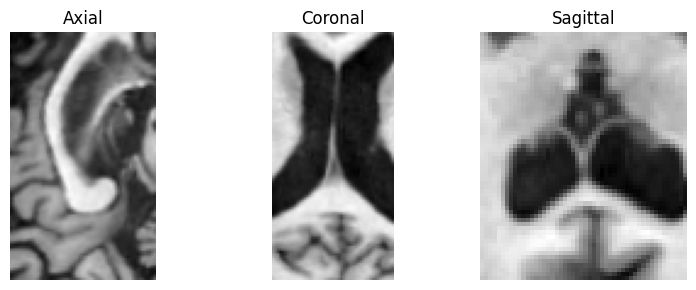

In [10]:
import matplotlib.pyplot as plt

# Load one MRI image
img = load_nifti(sampled_paths["adni"][0], DATA_PATH, target_shape=(50, 60, 102), start=[100, 80, 52])  # example: first ADNI scan
print("Image shape:", img.shape)  # should be (D, H, W) = (z, y, x)

# Pick middle slices
z_mid = img.shape[0] // 2  # axial
y_mid = img.shape[1] // 2  # coronal
x_mid = img.shape[2] // 2  # sagittal

# Plot
fig, axes = plt.subplots(1, 3, figsize=(8, 3))

# Axial (slice along z-axis)
axes[0].imshow(img[z_mid, :, :].T, cmap="gray", origin="lower")
axes[0].set_title("Axial")

# Coronal (slice along y-axis)
axes[1].imshow(img[:, y_mid, :].T, cmap="gray", origin="lower")
axes[1].set_title("Coronal")

# Sagittal (slice along x-axis)
axes[2].imshow(img[:, :, x_mid].T, cmap="gray", origin="lower")
axes[2].set_title("Sagittal")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [11]:
features_cache = {}
for dataset in preloaded_images.keys():
    print(f"Extract features {dataset}...")
    features_cache[dataset] = extract_features(preloaded_images[dataset], model, device=device)

Extract features adni...


Extracting features: 100%|██████████| 25/25 [00:00<00:00, 35.77it/s]


Extract features aibl...


Extracting features: 100%|██████████| 25/25 [00:00<00:00, 78.90it/s]


Extract features miriad...


Extracting features: 100%|██████████| 25/25 [00:00<00:00, 92.38it/s]


Extract features oasis3...


Extracting features: 100%|██████████| 25/25 [00:00<00:00, 109.02it/s]


Extract features slim...


Extracting features: 100%|██████████| 25/25 [00:00<00:00, 94.60it/s]


In [ ]:
datasets = list(sampled_paths.keys())
faed_matrix = np.zeros((len(datasets), len(datasets)))

print("Computing FAED matrix")
for i, d1 in enumerate(datasets):
    feats1 = features_cache[d1]

    for j, d2 in enumerate(datasets):
        print(f"Comparing {d1} and {d2}")
        feats2 = features_cache[d2]
        faed_matrix[i, j] = calculate_faed(feats1, feats2)


Computing FAED matrix
Comparing adni and adni


/tmp/ipykernel_199735/3262371264.py:48: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1 @ sigma2)


Comparing adni and aibl
Comparing adni and miriad
Comparing adni and oasis3
Comparing adni and slim
Comparing aibl and adni
Comparing aibl and aibl
Comparing aibl and miriad


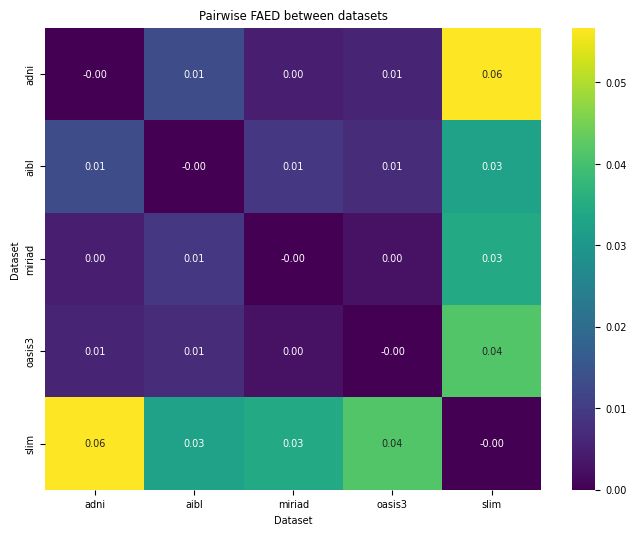

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

plt.figure(figsize=(8, 6))
sns.heatmap(faed_matrix, annot=True, fmt=".6f", xticklabels=datasets, yticklabels=datasets, cmap="viridis")
plt.title("Pairwise FAED between datasets")
plt.xlabel("Dataset")
plt.ylabel("Dataset")
plt.show()


## Distributions SSIM

In [1]:
%cd /home/maia-user/NeuroCBIR/

/home/maia-user/NeuroCBIR


In [2]:

from cbir.evaluation import retrieve_topk_for_queries
import pandas as pd
import os 
DATA_PATH = "/home/maia-user/cifs/Datasets/"

def load_dataset_whole_brain():
    # Constants
    embedding_file = "projected_embeddings.parquet"
    output_dir="data/results/whole_brain/eval_cl16/"
    
    # Load and filter metadata
    clinical_ds = [
        pd.read_csv(os.path.join(DATA_PATH, "ADNI", "metadata.csv")),
        pd.read_csv(os.path.join(DATA_PATH, "OASIS3", "metadata.csv")),
        pd.read_csv(os.path.join(DATA_PATH, "AIBL", "metadata.csv")),
        pd.read_csv(os.path.join(DATA_PATH, "SLIM", "metadata.csv")),
        pd.read_csv(os.path.join(DATA_PATH, "MIRIAD", "metadata.csv"))
    ]

    # Combine into a single DataFrame
    clinical_ds = pd.concat(clinical_ds, axis=0, ignore_index=True)


    # Load real features from parquet
    emb_path = os.path.join(output_dir, embedding_file)  # e.g., "outputs/embeddings.parquet"
    df_embs = pd.read_parquet(emb_path)

    # Ensure GUID is string and joinable
    df_embs["GUID"] = df_embs["GUID"].astype(str)
    clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)

    # Merge on GUID
    dataset = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")

    # Convert embedding columns into a single 'features' column of vectors
    embedding_cols = [col for col in df_embs.columns if col != "GUID"]
    dataset["features"] = dataset[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)
    return dataset

def load_dataset_region_brain():
    # Constants
    embedding_file = "projected_embeddings.parquet"
    output_dir="data/results/region_brain/eval_cl32/"
    
    # Load and filter metadata
    clinical_ds = [
        pd.read_csv(os.path.join(DATA_PATH, "ADNI", "metadata.csv")),
        pd.read_csv(os.path.join(DATA_PATH, "OASIS3", "metadata.csv")),
        pd.read_csv(os.path.join(DATA_PATH, "AIBL", "metadata.csv")),
        pd.read_csv(os.path.join(DATA_PATH, "SLIM", "metadata.csv")),
        pd.read_csv(os.path.join(DATA_PATH, "MIRIAD", "metadata.csv"))
    ]

    # Combine into a single DataFrame
    clinical_ds = pd.concat(clinical_ds, axis=0, ignore_index=True)

    # Load real features from parquet
    emb_path = os.path.join(output_dir, embedding_file)  # e.g., "outputs/embeddings.parquet"
    df_embs = pd.read_parquet(emb_path)

    # Ensure GUID is string and joinable
    df_embs["GUID"] = df_embs["GUID"].astype(str)
    df_embs["LabelName"] = df_embs["LabelName"].astype(str)
    clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)

    # Merge on GUID
    dataset = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")

    # Convert embedding columns into a single 'features' column of vectors
    embedding_cols = [col for col in df_embs.columns if not col in  ["GUID", "LabelName"]]
    dataset["features"] = dataset[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)
    
    # Load labels and bounding boxes for cortical/subcortical structures
    labels_df = pd.read_csv("data/labels.csv")
    bb_df = pd.read_csv("data/bounding_boxes.csv")
    labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column
    return dataset, labels_bb_df

# Load datasets
dataset_whole_brain = load_dataset_whole_brain()
dataset_region_brain, labels_bb_df = load_dataset_region_brain()


In [3]:
top_k = dataset_whole_brain.shape[0]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import nibabel as nib
import torch
import torch.nn.functional as F
from sklearn.metrics import mutual_info_score
from scipy.ndimage import zoom

def crop_mri(image, target_shape=(160, 176, 208), start=[48, 38, 10]):
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path, target_shape=(160, 176, 208), start=[48, 38, 10]):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata(), target_shape=target_shape, start=start)

def obtain_struct(brain_path, seg_path, DATA_PATH, target_struct_name, labels_bb_df, target_shape=[64,64,64]):
    image = load_nifti(brain_path, DATA_PATH).astype(np.float32)
    seg = load_nifti(seg_path, DATA_PATH)

    # Filter the label row for the selected structure
    struct_row_df = labels_bb_df.query(f"LabelName == '{target_struct_name}' and Use == 1").reset_index(drop=True)
    if len(struct_row_df) == 0:
        raise ValueError(f"Structure '{target_struct_name}' not found in labels_bb_df with Use == 1.")
    struct_row = struct_row_df.iloc[0]
    struct_map_id = struct_row["LabelID"]

    # Bounding box
    x1, x2 = int(struct_row["min_x"]) - 5, int(struct_row["max_x"]) + 5
    y1, y2 = int(struct_row["min_y"]) - 5, int(struct_row["max_y"]) + 5
    z1, z2 = int(struct_row["min_z"]) - 5, int(struct_row["max_z"]) + 5

    # Preprocess all samples
    patch_brain = image[x1:x2, y1:y2, z1:z2]
    patch_seg = (seg[x1:x2, y1:y2, z1:z2] == struct_map_id)

    struct = patch_brain * patch_seg
    
    # --- Resample to target_shape using trilinear interpolation ---
    zoom_factors = [t / s for t, s in zip(target_shape, struct.shape)]
    struct_resampled = zoom(struct, zoom_factors, order=1)  # order=1 = trilinear

    return struct_resampled

def preprocess_img(path, data_path, normalize=True, as_uint8=True, target_shape=(96,96,96)):
    img = load_nifti(path, data_path) #, target_shape=(50, 60, 102), start=[100, 80, 52])  # [D,H,W], float64

    # normalize to [0,1]
    if normalize:
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # convert to tensor for interpolation
    img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float()  # [1,1,D,H,W]

    # resample with trilinear interpolation
    if target_shape is not None:
        img_t = F.interpolate(
            img_t, size=target_shape, mode="trilinear", align_corners=False
        )

    img_resampled = img_t.squeeze().numpy()  # back to numpy [D,H,W]

    if as_uint8:
        img_resampled = (img_resampled * 255).astype(np.uint8)

    return img_resampled

def to_tensor(img_uint8):
    """Convert uint8 -> float32 [0,1] tensor [1,1,D,H,W]."""
    img = img_uint8.astype(np.float32) / 255.0
    return torch.from_numpy(img).unsqueeze(0).unsqueeze(0)  # [1,1,D,H,W]

def ncc(q, r, mask=None):
    qf = q.astype(np.float32)
    rf = r.astype(np.float32)
    if mask is None:
        qf = qf.flatten(); rf = rf.flatten()
    else:
        m = mask.astype(bool)
        qf = qf[m]; rf = rf[m]
    qf = (qf - qf.mean()) / (qf.std() + 1e-8)
    rf = (rf - rf.mean()) / (rf.std() + 1e-8)
    return float(np.mean(qf * rf))

def mutual_information(q, r, mask=None, n_bins=64):
    if mask is None:
        qv = q.flatten()
        rv = r.flatten()
    else:
        m = mask.astype(bool)
        qv = q[m]
        rv = r[m]
    # discretize
    bins = np.linspace(0.0, 1.0, n_bins+1)
    qdig = np.digitize(qv, bins) - 1
    rdig = np.digitize(rv, bins) - 1
    return mutual_info_score(qdig, rdig)

from skimage.metrics import structural_similarity as ssim

def ms_ssim_numpy(img1, img2, levels=5):
    mssim = []
    for _ in range(levels):
        score, _ = ssim(img1, img2, full=True, data_range=1.0)
        mssim.append(score)
        # downsample
        img1 = zoom(img1, 2, order=1)
        img2 = zoom(img2, 2, order=1)
    return np.mean(mssim)

def plot_query_and_topk(query_guid, retrieval_df, dataset, data_path, indexes=10, slice_axis=2):
    """
    Show the query image + top-k retrieved images (axial slice).
    One row, (k+1) columns.
    """
    
    N_i = len(indexes)
    # Find retrieved GUIDs for this query
    row = retrieval_df[retrieval_df["query"] == query_guid].iloc[0]
    retrieved_guids = row.values[indexes].tolist()  # top-k (skip the 'query' column)

    # Get file paths
    q_path = dataset.loc[dataset["GUID"] == query_guid, "brain"].values[0]
    r_paths = dataset.set_index("GUID").loc[retrieved_guids, "brain"].values

    # Load images
    q_img = preprocess_img(q_path, data_path)
    retrieved_imgs = [preprocess_img(rp, data_path) for rp in r_paths]

    # Pick middle axial slice
    def get_axial(img):
        mid = img.shape[slice_axis] // 2
        return img[:, mid, :] if slice_axis == 2 else img.take(mid, axis=slice_axis)

    q_slice = get_axial(q_img)
    r_slices = [get_axial(img) for img in retrieved_imgs]

    # Plot
    fig, axes = plt.subplots(1, N_i+1, figsize=(2*(N_i+1), 2))
    axes[0].imshow(q_slice.T, cmap="gray", origin="lower")
    axes[0].set_title("Query", fontsize=8)
    axes[0].axis("off")

    for i, (ax, idx) in enumerate(zip(axes[1:], indexes)):
        ax.imshow(r_slices[i].T, cmap="gray", origin="lower")
        ax.set_title(f"{idx}", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Example usage (replace with an actual query GUID you sampled):
# example_guid = queries["GUID"].iloc[0]
# plot_query_and_topk(example_guid, retrieval_df, dataset, DATA_PATH, indexes=retrieval_groups["A"]["indexes"])


In [ ]:
from IPython.display import clear_output
from joblib import Parallel, delayed
import json

def load_img(dataset, guid, target_struct_name, whole_brain=True):
    # load query
    if whole_brain:
        path = dataset.loc[dataset["GUID"] == guid, "brain"].values[0]
        img = preprocess_img(path, DATA_PATH, as_uint8=False, target_shape=[64, 64, 64], normalize=False)
    else:
        brain_path = dataset.loc[dataset["GUID"] == guid, "brain"].values[0]
        seg_path = dataset.loc[dataset["GUID"] == guid, "seg"].values[0]
        img = obtain_struct(brain_path, seg_path, DATA_PATH, target_struct_name, labels_bb_df)
    return img

def process_retrieved_path(rp, q_img, dataset, whole_brain, target_struct_name):
    # r_img = preprocess_img(rp, DATA_PATH, as_uint8=False, target_shape=[64, 64, 64], normalize=False)
    r_img = load_img(dataset, rp, target_struct_name, whole_brain=whole_brain)
    
    # score = ncc(q_img, r_img)
    score = ssim(q_img, r_img, data_range=1.0)
    # score = ms_ssim_numpy(q_img, r_img)
    return score

def compute_retrieval_groups(dataset, whole_brain=True, target_struct_name="Left-Hippocampus", seed = 42):
    
    # Inputs
    if not whole_brain:
        dataset = dataset.query(f"LabelName == '{target_struct_name}'").reset_index()
        
    
    top_k = dataset.shape[0]
    
    # Queries
    N_queries = 30
    queries = dataset.query("project == 'oasis3'").sample(n=N_queries, random_state=seed)
    retrieval_df = retrieve_topk_for_queries(dataset, queries, top_k=top_k)

    # Retrieval groups
    retrieval_groups = {}
    retrieval_groups.update({
        "A": {"min_val": 1, "max_val": 11, "size": 10, "indexes": list(range(1, 11)), "results": [], "mean_res": []},
        "B": {"min_val": 11, "max_val": 51, "size": 10, "results": [], "mean_res": []},
        "C": {"min_val": 51, "max_val": 201, "size": 30, "results": [], "mean_res": []},
        "D": {"min_val": 201, "max_val": 1001, "size": 30, "results": [], "mean_res": []},
        "E": {"min_val": 1001, "max_val": 10001, "size": 30, "results": [], "mean_res": []},
        "F": {"min_val": 10001, "max_val": top_k, "size": 30, "results": [], "mean_res": []},    
    })

    # Generate indexes
    rng = np.random.default_rng(seed=seed)
    for key in retrieval_groups.keys():
        if not "indexes" in retrieval_groups[key]:
            retrieval_groups[key]["indexes"] = rng.choice(range(
                                        retrieval_groups[key]["min_val"], retrieval_groups[key]["max_val"]), 
                                        size=retrieval_groups[key]["size"], 
                                        replace=False).tolist()

    # Iter throughout queries
    pbar = tqdm(
        enumerate(retrieval_df.iterrows()), 
        total=len(retrieval_df),
        ncols=120,  # width of the bar in characters
        desc="Computing for query X out of X. Group X"
    )
    for i, (idx, row) in pbar:
        q_guid = row["query"] # Query  
        
        # load query
        q_img = load_img(dataset, q_guid, target_struct_name, whole_brain=whole_brain)
            
        # Iter in retrieval_groups
        for key in retrieval_groups.keys():
            pbar.set_description(f"Computing for query {i+1} out of {N_queries}. Group {key}")
            indexes = retrieval_groups[key]["indexes"]
            retrieved_guids = row.values[indexes].tolist()

            # get paths from dataset
            # r_paths = (
            #     dataset.set_index("GUID")
            #         .loc[retrieved_guids, "brain"]
            #         .values
            # )

            # --- parallelized loop ---
            scores = Parallel(n_jobs=6)(
                delayed(process_retrieved_path)(r_guid, q_img, dataset, whole_brain, target_struct_name) for r_guid in retrieved_guids
            )

            retrieval_groups[key]["results"].append(scores)
            retrieval_groups[key]["mean_res"].append(np.mean(scores))
        # clear_output(wait=False)
    return retrieval_groups


In [ ]:

# Compute retrival groups
retrieval_groups_whole_brain = compute_retrieval_groups(dataset_whole_brain, seed=1234)
retrieval_groups_hippocampus = compute_retrieval_groups(dataset_region_brain, whole_brain=False, target_struct_name="Left-Hippocampus")
retrieval_groups_thalamus = compute_retrieval_groups(dataset_region_brain, whole_brain=False, target_struct_name="Left-Thalamus", seed=1234)
retrieval_groups_amygdala = compute_retrieval_groups(dataset_region_brain, whole_brain=False, target_struct_name="Left-Amygdala")


Computing for query 30 out of 30. Group F: 100%|████████████████████████████████████████| 30/30 [12:58<00:00, 25.95s/it]


In [37]:

# Save vars
# Collect all groups
all_retrieval_groups = {
    "whole_brain": retrieval_groups_whole_brain,
    "Left-Hippocampus": retrieval_groups_hippocampus,
    "Left-Thalamus": retrieval_groups_thalamus,
    "Left-Amygdala": retrieval_groups_amygdala}

# Save to JSON
save_path = "./figures/boxplot_vars_ssim.json"
with open(save_path, "w") as f:
    json.dump(all_retrieval_groups, f, indent=2)

print(f"Saved retrieval groups to {save_path}")

Saved retrieval groups to ./figures/boxplot_vars_ssim.json


In [11]:
%cd /home/maia-user/NeuroCBIR/

import json

# Load variables
with open("./figures/boxplot_vars_ssim.json", "r") as f:
    boxplot_vars = json.load(f)

# Extract them
# retrieval_groups_whole_brain = boxplot_vars["whole_brain"]
retrieval_groups_hippocampus = boxplot_vars["Left-Hippocampus"]
retrieval_groups_thalamus = boxplot_vars["Left-Thalamus"]
retrieval_groups_amygdala = boxplot_vars["Left-Amygdala"]

/home/maia-user/NeuroCBIR


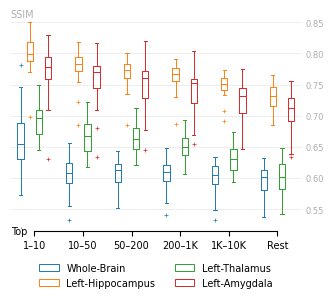

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# ✅ Step 1: helper to flatten results
def prepare_bp_data(retrieval_groups, structure_name):
    bp_data = {"y": [], "x": [], "structure": []}
    for key in retrieval_groups.keys():
        bp_data["y"].extend(retrieval_groups[key]["mean_res"])
        bp_data["x"].extend([key] * len(retrieval_groups[key]["mean_res"]))
        bp_data["structure"].extend([structure_name] * len(retrieval_groups[key]["mean_res"]))
    return bp_data

# ✅ Step 2: collect all structures into one dataframe-like dict
bp_whole = prepare_bp_data(retrieval_groups_whole_brain, "Whole-Brain")
bp_hippo = prepare_bp_data(retrieval_groups_hippocampus, "Left-Hippocampus")
bp_thal  = prepare_bp_data(retrieval_groups_thalamus, "Left-Thalamus")
bp_amyg  = prepare_bp_data(retrieval_groups_amygdala, "Left-Amygdala")

bp_all = {
    "y": bp_whole["y"] + bp_hippo["y"] + bp_thal["y"] + bp_amyg["y"],
    "x": bp_whole["x"] + bp_hippo["x"] + bp_thal["x"] + bp_amyg["x"],
    "structure": bp_whole["structure"] + bp_hippo["structure"] + bp_thal["structure"] + bp_amyg["structure"]
}


# ✅ Step 3: nicer labels for x-axis
group_labels = {
    "A": "1–10",
    "B": "10–50",
    "C": "50–200",
    "D": "200–1K",
    "E": "1K–10K",
    "F": "Rest"
}
bp_all["x"] = [group_labels[g] for g in bp_all["x"]]

# ✅ Step 4: plot

# Example palette
edge_palette = {
    "Whole-Brain": "#1f77b4",      # blue
    "Left-Hippocampus": "#ff7f0e", # orange
    "Left-Thalamus": "#2ca02c",    # green
    "Left-Amygdala": "#d62728"     # red
}

cm = 1/2.54 
plt.figure(figsize=(8.5*cm, 8*cm))
grid_color = "#e7e7e7"
plt.grid(color=grid_color)

# Create seaborn boxplot
ax = sns.boxplot(
    data=bp_all,
    x="x",
    y="y",
    hue="structure",
    palette=edge_palette,
    showcaps=True,
    fill=False, 
    gap=.3,
    width=0.75,
    linewidth=0.7,
    flierprops=dict(marker="+", markersize=3, markeredgewidth=0.5),
    # medianprops=dict(color="black"),
    # whiskerprops=dict(color="black"),
    # capprops=dict(color="black")
)
sns.despine(offset=2, trim=True, left=True)

# Set title, labels, legend
ax.set_title("SSIM", fontsize=7, color="#afaeae", loc='left', pad=-10)
ax.set_ylabel("")
ax.set_ylim([0.52, 0.855])
# ax.set_ylabel("NCC", rotation=0, color="#afaeae")
# ax.yaxis.set_label_coords(0.04,1.01)

ax.set_xlabel("Top")
ax.xaxis.set_label_coords(0.03,0.01)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_ticks_position('none') 
ax.tick_params(axis='y', which='major', pad=-1, labelcolor="#afaeae", labelsize=6, 
               labelleft=False, labelright=True, grid_linewidth=0.5)

plt.legend(title="", loc="lower center", ncol=1, 
        #    frameon=False,
           fancybox=True,
           facecolor="w",
           edgecolor="w",
           bbox_to_anchor=(0.5, -0.33),
           ncols=2,
           )
plt.tight_layout()
plt.savefig(f"figures/sim_eval.pdf", format='pdf', 
bbox_inches='tight', pad_inches=0)
plt.show()

In [46]:
from scipy.stats import spearmanr

# Organize retrieval_groups for all structures
structures = {
    "Whole Brain": retrieval_groups_whole_brain,
    "Left Hippocampus": retrieval_groups_hippocampus,
    "Left Thalamus": retrieval_groups_thalamus,
    "Left Amygdala": retrieval_groups_amygdala
}

# Define group ordering (numeric rank for correlation)
group_order = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6}

results = {}

for struct_name, groups in structures.items():
    all_scores = []
    group_ranks = []
    
    for group_label in groups.keys():
        scores = groups[group_label]["mean_res"]
        all_scores.extend(scores)
        group_ranks.extend([group_order[group_label]] * len(scores))
    
    corr, pval = spearmanr(group_ranks, all_scores)
    results[struct_name] = {"spearman_r": corr, "p_value": pval}

# Display results
import pandas as pd
pd.DataFrame(results).T


,spearman_r,p_value
Whole Brain,-0.401048,2.417441e-08
Left Hippocampus,-0.754265,2.359624e-34
Left Thalamus,-0.744749,4.330550e-33
Left Amygdala,-0.572147,4.862933e-17
